In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# File path in Google Drive
file_path = '/content/drive/My Drive/modis_2023_Brazil.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pandas matplotlib seaborn scikit-learn


In [ ]:
!ls /content/


drive  modis_2023_Brazil.xlsx  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls '/content/drive/My Drive/'


'CEN 6940- Computing Practicum'  'Colab Notebooks'   modis_2023_Brazil.gsheet


In [ ]:
file_path = '/content/drive/My Drive/modis_2023_Brazil.xlsx'


In [ ]:
!pip install openpyxl


In [ ]:
import pandas as pd

# Path to the Excel file
file_path = '/content/modis_2023_Brazil.xlsx'  # Update if using Google Drive

# Load the Excel dataset
data = pd.read_excel(file_path)

# Explore the dataset
print(data.head())
print(data.info())


   latitude  longitude  brightness  scan  track   acq_date  acq_time  \
0  -13.2689   -45.5637       323.4   1.1    1.0 2023-01-01       128   
1  -13.2704   -45.5736       311.9   1.1    1.0 2023-01-01       128   
2  -13.3373   -44.1169       303.3   1.3    1.1 2023-01-01       128   
3  -13.2674   -45.5538       320.0   1.1    1.0 2023-01-01       128   
4  -22.9089   -43.7306       312.7   1.1    1.0 2023-01-01       418   

  satellite instrument  confidence  version  bright_t31   frp daynight  type  
0     Terra      MODIS         100    61.03       291.7  23.8        N     0  
1     Terra      MODIS          84    61.03       291.1  12.2        N     0  
2     Terra      MODIS          54    61.03       292.5   7.0        N     0  
3     Terra      MODIS         100    61.03       291.2  20.0        N     0  
4      Aqua      MODIS          85    61.03       293.3  11.1        N     2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357737 entries, 0 to 357736
Data columns (t

In [ ]:
# Display basic information about the dataset
print(data.info())  # Column names, data types, and non-null counts

# Show summary statistics for numerical columns
print(data.describe())

# Display the first few rows of the dataset
print(data.head())

# Check for missing values
print(data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357737 entries, 0 to 357736
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   latitude    357737 non-null  float64       
 1   longitude   357737 non-null  float64       
 2   brightness  357737 non-null  float64       
 3   scan        357737 non-null  float64       
 4   track       357737 non-null  float64       
 5   acq_date    357737 non-null  datetime64[ns]
 6   acq_time    357737 non-null  int64         
 7   satellite   357737 non-null  object        
 8   instrument  357737 non-null  object        
 9   confidence  357737 non-null  int64         
 10  version     357737 non-null  float64       
 11  bright_t31  357737 non-null  float64       
 12  frp         357737 non-null  float64       
 13  daynight    357737 non-null  object        
 14  type        357737 non-null  int64         
dtypes: datetime64[ns](1), float64(8), int64(3), object(

In [ ]:
print(data.columns)


Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type'],
      dtype='object')


In [ ]:
print(data.dtypes)


latitude             float64
longitude            float64
brightness           float64
scan                 float64
track                float64
acq_date      datetime64[ns]
acq_time               int64
satellite             object
instrument            object
confidence             int64
version              float64
bright_t31           float64
frp                  float64
daynight              object
type                   int64
dtype: object


In [ ]:
print(data.head())


   latitude  longitude  brightness  scan  track   acq_date  acq_time  \
0  -13.2689   -45.5637       323.4   1.1    1.0 2023-01-01       128   
1  -13.2704   -45.5736       311.9   1.1    1.0 2023-01-01       128   
2  -13.3373   -44.1169       303.3   1.3    1.1 2023-01-01       128   
3  -13.2674   -45.5538       320.0   1.1    1.0 2023-01-01       128   
4  -22.9089   -43.7306       312.7   1.1    1.0 2023-01-01       418   

  satellite instrument  confidence  version  bright_t31   frp daynight  type  
0     Terra      MODIS         100    61.03       291.7  23.8        N     0  
1     Terra      MODIS          84    61.03       291.1  12.2        N     0  
2     Terra      MODIS          54    61.03       292.5   7.0        N     0  
3     Terra      MODIS         100    61.03       291.2  20.0        N     0  
4      Aqua      MODIS          85    61.03       293.3  11.1        N     2  


In [ ]:
# Convert 'acq_date' to a datetime object and then to an integer timestamp
data['acq_date'] = pd.to_datetime(data['acq_date'])
data['acq_date'] = data['acq_date'].astype('int64') // 10**6  # Convert to milliseconds since epoch


In [ ]:
data = pd.get_dummies(data, drop_first=True)


In [ ]:
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357737 entries, 0 to 357736
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   latitude         357737 non-null  float64
 1   longitude        357737 non-null  float64
 2   brightness       357737 non-null  float64
 3   scan             357737 non-null  float64
 4   track            357737 non-null  float64
 5   acq_date         357737 non-null  int64  
 6   acq_time         357737 non-null  int64  
 7   confidence       357737 non-null  int64  
 8   version          357737 non-null  float64
 9   bright_t31       357737 non-null  float64
 10  frp              357737 non-null  float64
 11  type             357737 non-null  int64  
 12  satellite_Terra  357737 non-null  bool   
 13  daynight_N       357737 non-null  bool   
dtypes: bool(2), float64(8), int64(4)
memory usage: 33.4 MB
None


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming 'data' is already loaded

# Define features (X) and target (y)
# If 'brightness' is continuous, convert it into categorical
data['brightness_category'] = pd.cut(data['brightness'], bins=3, labels=[0, 1, 2])

X = data.drop('brightness_category', axis=1)  # Remove the old brightness column
y = data['brightness_category']  # New categorical target

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

# Print accuracy
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logreg)}")


Logistic Regression Accuracy: 0.9707469111645329


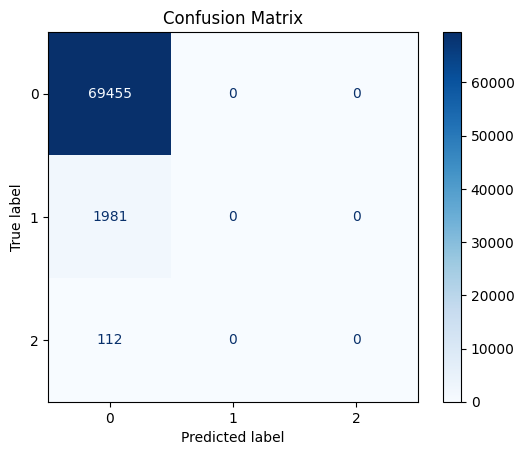

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     69455
           1       0.00      0.00      0.00      1981
           2       0.00      0.00      0.00       112

    accuracy                           0.97     71548
   macro avg       0.32      0.33      0.33     71548
weighted avg       0.94      0.97      0.96     71548



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_logreg)

# Display confusion matrix
ConfusionMatrixDisplay(conf_matrix, display_labels=logreg.classes_).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_logreg))


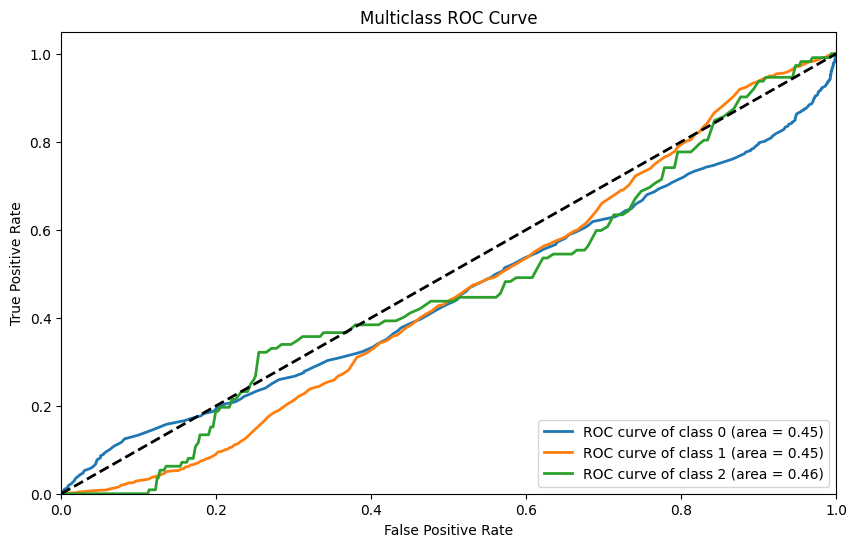

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Assuming you have already trained your Logistic Regression model as 'logreg'
# and have your test data as X_test and y_test

# Binarize the target labels
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# Get predicted probabilities for all classes
y_pred_proba = logreg.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1] # Number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.show()

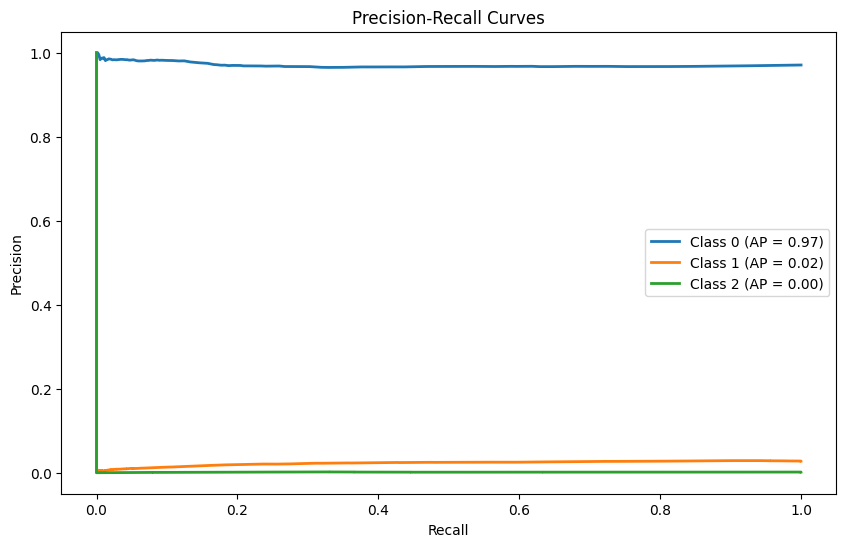

Average Precision for Class 0: 0.97
Average Precision for Class 1: 0.02
Average Precision for Class 2: 0.00


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize the target labels for multi-class
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # assuming 3 classes

# Calculate precision and recall for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(y_test_bin.shape[1]):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(10, 6))
for i in range(y_test_bin.shape[1]):
    plt.plot(recall[i], precision[i], lw=2, label=f'Class {i} (AP = {average_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='best')
plt.show()

# Print average precision scores
for i in range(y_test_bin.shape[1]):
    print(f'Average Precision for Class {i}: {average_precision[i]:.2f}')


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Print confusion matrix for each class
for i in range(y_test_bin.shape[1]):
    cm = confusion_matrix(y_test_bin[:, i], y_pred_proba[:, i] > 0.5)
    print(f'Confusion Matrix for Class {i}:\n{cm}\n')


Confusion Matrix for Class 0:
[[    0  2093]
 [    0 69455]]

Confusion Matrix for Class 1:
[[69567     0]
 [ 1981     0]]

Confusion Matrix for Class 2:
[[71436     0]
 [  112     0]]



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_bin, y_pred_proba > 0.5))


              precision    recall  f1-score   support

           0       0.97      1.00      0.99     69455
           1       0.00      0.00      0.00      1981
           2       0.00      0.00      0.00       112

   micro avg       0.97      0.97      0.97     71548
   macro avg       0.32      0.33      0.33     71548
weighted avg       0.94      0.97      0.96     71548
 samples avg       0.97      0.97      0.97     71548



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


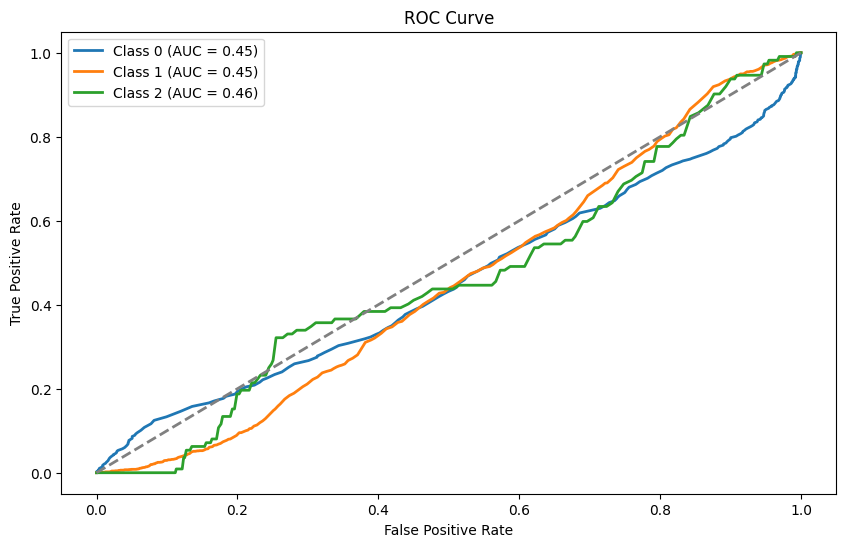

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()


Feature Importance for Logistic Regression:


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# Extract coefficients
coefficients = logreg.coef_[0]

# Get feature importance (sorted by absolute value)
importance_indices = np.argsort(np.abs(coefficients))[::-1]

print("Feature Importances from Logistic Regression:")
for i in range(X_train.shape[1]):
    print(f"{X.columns[importance_indices[i]]}: {coefficients[importance_indices[i]]}")


Feature Importances from Logistic Regression:
acq_date: 1.9736344006069798e-12
frp: -8.718005653284351e-21
acq_time: -6.784136781122713e-21
brightness: -1.429953817940082e-21
confidence: -7.595525323442689e-22
bright_t31: 9.682002154192424e-23
version: 7.225851385631221e-23
longitude: -5.201460557392582e-23
scan: 8.328217292296311e-24
satellite_Terra: 6.312978259638371e-24
daynight_N: 5.221101014043757e-24
track: 3.492909863601644e-24
latitude: 1.0167829653463209e-24
type: 6.8966189086415835e-25
